The second edition of *Think Complexity* is available from [Bookshop.org](https://bookshop.org/a/98697/9781492040200) and [Amazon](https://amzn.to/3wPN0SJ) (those are affiliate links). If you are enjoying the free, online version, consider [buying me a coffee](https://buymeacoffee.com/allendowney).

# Herds, Flocks, and Traffic Jams

The agent-based models in the previous chapter are based on grids: the agents occupy discrete locations in two-dimensional space. In this chapter we consider agents that move is continuous space, including simulated cars on a one-dimensional highway and simulated birds in three-dimensional space.

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ThinkComplexity/blob/v3/soln/chap10.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)
    
download('https://github.com/AllenDowney/ThinkComplexity/raw/v3/nb/utils.py')
download('https://github.com/AllenDowney/ThinkComplexity/raw/v3/nb/Cell2D.py')

In [3]:
from utils import decorate, savefig
# make a directory for figures
!mkdir -p figs

## Traffic jams

What causes traffic jams? Sometimes there is an obvious cause, like an accident, a speed trap, or something else that disturbs the flow of traffic. But other times traffic jams appear for no apparent reason.

Agent-based models can help explain spontaneous traffic jams. As an example, I implement a highway simulation based on a model in Mitchell Resnick's book, *Turtles, Termites and Traffic Jams*.

The agents in this model are drivers. Here's the definition for the `Driver` class:

In [4]:
class Driver:
    
    def __init__(self, loc, speed=4):
        """Initialize the attributes.
        
        loc: position on track, in miles
        speed: speed in miles per hour
        """
        self.start = loc
        self.loc = loc
        self.speed = speed
        
    def choose_acceleration(self, dist):
        """Chooses acceleration based on distance.
        
        dist: distance from the car in front
        
        returns: acceleration
        """
        return 1
        
    def set_odometer(self):
        self.start = self.loc
        
    def read_odometer(self):
        return self.loc - self.start

The attributes `loc` and `speed` are the location and speed of the driver. `set_odometer` and `read_odometer` keep track of the distance a driver travels, which we'll use to compute average speed.

This implementation of `choose_acceleration` is simple: it always accelerates at the maximum rate.

Here's the class that represents the "highway":

In [5]:
from Cell2D import Cell2D

class Highway(Cell2D):
    
    max_acc = 1
    min_acc = -10
    speed_limit = 40
    
    def __init__(self, n=10, length=1000, eps=0, constructor=Driver):
        """Initializes the attributes.
        
        n: number of drivers
        length: length of the track
        eps: variability in speed
        constructor: function used to instantiate drivers
        """
        self.length = length
        self.eps = eps
        self.crashes = 0

        # create the drivers
        locs = np.linspace(0, length, n, endpoint=False)
        self.drivers = [constructor(loc) for loc in locs]
        
        # and link them up
        for i in range(n):
            j = (i+1) % n
            self.drivers[i].next = self.drivers[j]
            
    def distance(self, driver):
        """Distance from `driver` to next driver.
        
        driver: Driver object
        """
        dist = driver.next.loc - driver.loc
        # fix wraparound
        if dist < 0:
            dist += self.length
        return dist
    
    def set_odometers(self):
        return [driver.set_odometer()
                for driver in self.drivers] 
    
    def read_odometers(self):
        return np.mean([driver.read_odometer()
                        for driver in self.drivers])
    
    def draw(self):
        """Draws the drivers and shows collisions.
        """
        drivers = self.drivers
        xs, ys = self.get_coords(drivers)
        plt.plot(xs, ys, 'bs', markersize=10, alpha=0.7)
        
        stopped = [driver for driver in self.drivers 
                  if driver.speed==0]
        xs, ys = self.get_coords(stopped, r=0.8)
        plt.plot(xs, ys, 'r^', markersize=12, alpha=0.7)
        
        plt.axis('off')
        plt.axis('equal')
        plt.xlim([-1.05, 1.05])
        plt.ylim([-1.05, 1.05])

    def get_coords(self, drivers, r=1):
        """Gets the coordinates of the drivers.
        
        Transforms from (row, col) to (x, y).
        
        drivers: sequence of Driver
        r: radius of the circle
        
        returns: tuple of sequences, (xs, ys)
        """
        locs = np.array([driver.loc for driver in drivers])
        locs *= 2 * np.pi / self.length
        xs = r * np.cos(locs)
        ys = r * np.sin(locs)
        return xs, ys

`n` is the number of cars, `length` is the length of the highway, and `eps` is the amount of random noise we'll add to the system. `constructor` is the function used to make the drivers; by default it is `Driver`.

`locs` contains the locations of the drivers; the NumPy function `linspace` creates an array of `n` locations equally spaced between `0` and `length`.

The `drivers` attribute is a list of `Driver` objects. The `for` loop links them so each `Driver` contains a reference to the next. The highway is circular, so the last `Driver` contains a reference to the first.

During each time step, the `Highway` moves each of the drivers:

In [6]:
%%add_method_to Highway

    def step(self):
        """Performs one time step."""
        for driver in self.drivers:
            self.move(driver)

The `move` method lets the `Driver` choose its acceleration. Then `move` computes the updated speed and position. Here's the implementation:

In [7]:
%%add_method_to Highway

    def move(self, driver):
        """Updates `driver`.
        
        driver: Driver object
        """
        # get the distance to the next driver
        dist = self.distance(driver)

        # let the driver choose acceleration
        acc = driver.choose_acceleration(dist)
        acc = min(acc, self.max_acc)
        acc = max(acc, self.min_acc)
        speed = driver.speed + acc
            
        # add random noise to speed
        speed *= np.random.uniform(1-self.eps, 1+self.eps)
        
        # keep it nonnegative and under the speed limit
        speed = max(speed, 0)
        speed = min(speed, self.speed_limit)
        
        # if current speed would collide with next driver, stop
        if speed > dist:
            speed = 0
            self.crashes += 1
            
        # update speed and loc
        driver.speed = speed
        driver.loc += speed

`dist` is the distance between `driver` and the next driver ahead. This distance is passed to `choose_acceleration`, which specifies the behavior of the driver. This is the only decision the driver gets to make; everything else is determined by the "physics" of the simulation.

-   `acc` is acceleration, which is bounded by `min_acc` and `max_acc`. In my implementation, cars can accelerate with `max_acc=1` and brake with `min_acc=-10`.

-   `speed` is the old speed plus the requested acceleration, but then we make some adjustments. First, we add random noise to `speed`, because the world is not perfect. `eps` determines the magnitude of the relative error; for example, if `eps` is 0.02, `speed` is multiplied by a random factor between 0.98 and 1.02.

-   Speed is bounded between 0 and `speed_limit`, which is 40 in my implementation, so cars are not allowed to go backward or speed.

-   If the requested speed would cause a collision with the next car, `speed` is set to 0.

-   Finally, we update the `speed` and `loc` attributes of `driver`.

Since the cars start out equally spaced, we expect them all to accelerate until they reach the speed limit, or until their speed exceeds the space between them. At that point, at least one "collision" will occur, causing some cars to stop.

Here's an animation of the process, starting with 30 cars and `eps=0.02`:

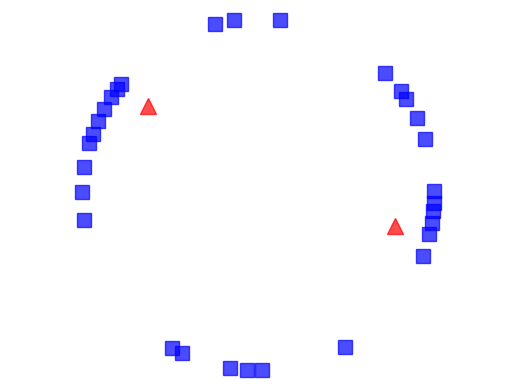

In [8]:
highway = Highway(30, eps=0.02)
highway.animate(frames=50, interval=0.2)

The following figure shows a few steps in this process. Squares indicate the position of the drivers; triangles indicate places where one driver has to brake to avoid another.

Saving figure to file figs/chap10-1


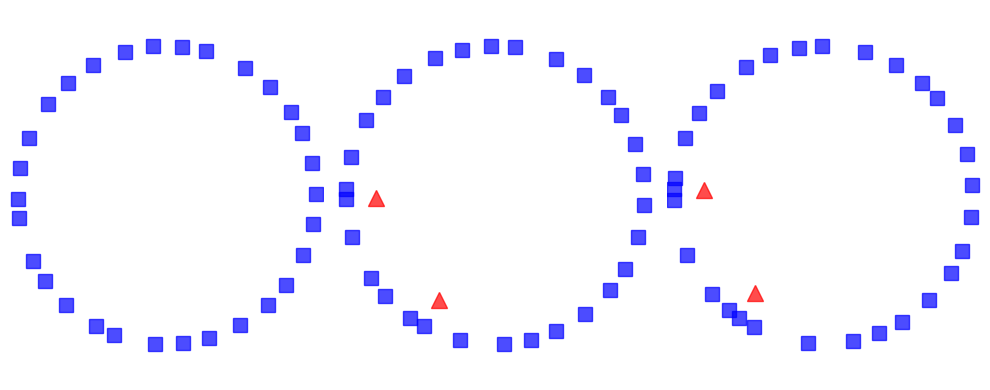

In [9]:
from utils import three_frame

highway = Highway(30, eps=0.02)
three_frame(highway, [16, 1, 1], seed=22)
savefig('figs/chap10-1')

On the left is the configuration after 16 time steps, with the highway mapped to a circle. Because of random noise, some cars are going faster than others, and the spacing has become uneven.

During the next time step (middle) there are two collisions, indicated by the triangles.

During the next time step (right) two cars collide with the stopped cars, and we can see the initial formation of a traffic jam. Once a jam forms, it tends to persist, with additional cars approaching from behind and colliding, and with cars in the front accelerating away.

Under some conditions, the jam itself propagates backwards, as you can see in the animation.

## Random perturbation

As the number of cars increases, traffic jams become more severe. To see how much, the following function runs simulations with a range of numbers of cars and computes the average speed the cars are able to achieve.

In [10]:
def run_simulation(eps, constructor=Driver, iters=100):
    res = []
    for n in range(5, 100, 5):
        highway = Highway(n, eps=eps, constructor=constructor)
        for i in range(iters):
            highway.step()

        highway.set_odometers()
        for i in range(iters):
            highway.step()

        res.append((n, highway.read_odometers() / iters))
    
    return np.transpose(res)

The following figure shows average speed as a function of the number of cars, for three magnitudes of added random noise.

Saving figure to file figs/chap10-2


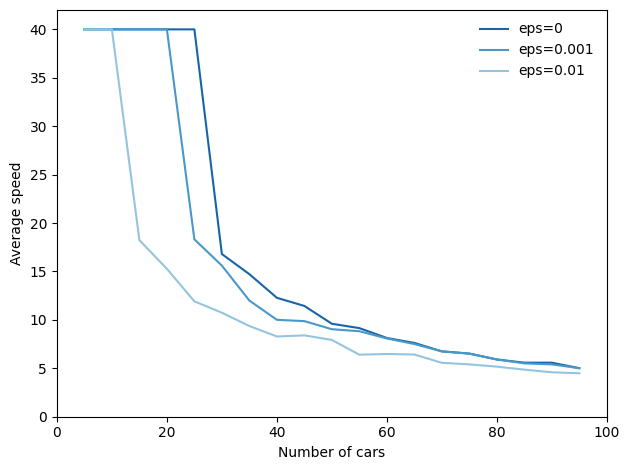

In [11]:
np.random.seed(20)
from utils import set_palette
set_palette('Blues', 4, reverse=True)

results = {}
for eps in [0.0, 0.001, 0.01]:
    xs, ys = run_simulation(eps)
    results[eps] = xs, ys
    plt.plot(xs, ys, label='eps=%g' % eps)
    
decorate(xlabel='Number of cars',
                 ylabel='Average speed',
                 xlim=[0, 100], ylim=[0, 42])

savefig('figs/chap10-2')

The top line shows results with `eps=0`, that is, with no random variation in speed. With 25 or fewer cars, the spacing between cars is greater than 40, which allows cars to reach and maintain the maximum speed, which is 40. With more than 25 cars, traffic jams form and the average speed drops quickly.

This effect is a direct result of the physics of the simulation, so it should not be surprising. If the length of the road is 1000, the spacing between `n` cars is `1000/n`. And since cars can't move faster than the space in front of them, the highest average speed we expect is `1000/n` or 40, whichever is less.

But that's the best case scenario. With just a small amount of randomness, things get much worse.

The figure also shows results with `eps=0.001` and `eps=0.01`, which correspond to errors in speed of 0.1% and 1%.

To quantify how much worse, we can compute the capacity of the highway, by which I mean the maximum number of cars that can reach and sustain the speed limit. The following loop computes the capacity for each value of `eps`, counting an average speed above 39 as reaching the speed limit.

In [12]:
for eps, (xs, ys) in results.items():
    capacity = max(n for n, y in zip(xs, ys) if y > 39)
    print(f'eps={eps:g}: capacity {capacity:.0f}')

eps=0: capacity 25
eps=0.001: capacity 20
eps=0.01: capacity 10


With no errors, the capacity is 25. With 0.1% errors, it drops to 20. And with 1% errors, it drops to 10. Ugh.

As one of the exercises at the end of this chapter, you'll have a chance to design a better driver; that is, you will experiment with different strategies in `choose_acceleration` and see if you can find driver behaviors that improve average speed.

## Boids

In 1987 Craig Reynolds published "Flocks, herds and schools: A distributed behavioral model", which describes an agent-based model of herd behavior. You can download his paper from <https://thinkcomplex.com/boid>.

Agents in this model are called "Boids", which is both a contraction of "bird-oid" and an accented pronunciation of "bird" (although Boids are also used to model fish and herding land animals).

Each agent simulates three behaviors:

**Flock centering:** Move toward the center of the flock.

**Collision avoidance:** Avoid obstacles, including other Boids.

**Velocity matching:** Align velocity (speed and direction) with neighboring Boids.

Boids make decisions based on local information only; each Boid only sees (or pays attention to) other Boids in its field of vision.

In the repository for this book, you will find `Boids7.py`, which contains my implementation of Boids, based in part on the description in Gary William Flake's book, *The Computational Beauty of Nature*.

My implementation uses VPython, which is a library that provides 3-D graphics. VPython provides a `Vector` object, which I use to represent the position and velocity of Boids in three dimensions. You can read about them at <https://thinkcomplex.com/vector>.

VPython doesn't run in this notebook (or on Colab), so the code in the next two sections is shown but not run. One of the exercises at the end of the chapter explains how to run `Boids7.py`.

## The Boid algorithm

`Boids7.py` defines two classes: `Boid`, which implements the Boid behaviors, and `World`, which contains a list of Boids and a "carrot" the Boids are attracted to.

The `Boid` class defines the following methods:

-   `center`: Finds other Boids within range and computes a vector toward their centroid.

-   `avoid`: Finds objects, including other Boids, within a given range, and computes a vector that points away from their centroid.

-   `align`: Finds other Boids within range and computes the average of their headings.

-   `love`: Computes a vector that points toward the carrot.

Here's the implementation of `center`:

```python
    def center(self, boids, radius=1, angle=1):
        neighbors = self.get_neighbors(boids, radius, angle)
        vecs = [boid.pos for boid in neighbors]
        return self.vector_toward_center(vecs)
```

The parameters `radius` and `angle` are the radius and angle of the field of view, which determines which other Boids are taken into consideration. `radius` is in arbitrary units of length; `angle` is in radians.

`center` uses `get_neighbors` to get a list of `Boid` objects that are in the field of view. `vecs` is a list of `Vector` objects that represent their positions.

Finally, `vector_toward_center` computes a `Vector` that points from `self` to the centroid of `neighbors`.

Here's how `get_neighbors` works:

```python
    def get_neighbors(self, boids, radius, angle):
        neighbors = []
        for boid in boids:
            if boid is self:
                continue
            offset = boid.pos - self.pos

            # if not in range, skip it
            if offset.mag > radius:
                continue

            # if not within viewing angle, skip it
            diff = self.vel.diff_angle(offset)
            if abs(diff) > angle:
                continue

            # otherwise add it to the list
            neighbors.append(boid)

        return neighbors
```

For each other Boid, `get_neighbors` uses vector subtraction to compute the vector from `self` to `boid`. The magnitude of this vector is the distance between them; if this magnitude exceeds `radius`, we ignore `boid`.

`diff_angle` computes the angle between the velocity of `self`, which points in the direction the Boid is heading, and the position of `boid`. If this angle exceeds `angle`, we ignore `boid`.

Otherwise `boid` is in view, so we add it to `neighbors`.

Now here's the implementation of `vector_toward_center`, which computes a vector from `self` to the centroid of its neighbors.

```python
    def vector_toward_center(self, vecs):
        if vecs:
            center = np.mean(vecs)
            toward = vector(center - self.pos)
            return limit_vector(toward)
        else:
            return null_vector
```

VPython vectors work with NumPy, so `np.mean` computes the mean of `vecs`, which is a sequence of vectors. `limit_vector` limits the magnitude of the result to 1; `null_vector` has magnitude 0.

We use the same helper methods to implement `avoid`:

```python
    def avoid(self, boids, carrot, radius=0.3, angle=np.pi):
        objects = boids + [carrot]
        neighbors = self.get_neighbors(objects, radius, angle)
        vecs = [boid.pos for boid in neighbors]
        return -self.vector_toward_center(vecs)
```

`avoid` is similar to `center`, but it takes into account the carrot as well as the other Boids. Also, the parameters are different: `radius` is smaller, so Boids only avoid objects that are too close, and `angle` is wider, so Boids avoid objects from all directions. Finally, the result from `vector_toward_center` is negated, so it points *away* from the centroid of any objects that are too close.

Here's the implementation of `align`:

```python
    def align(self, boids, radius=0.5, angle=1):
        neighbors = self.get_neighbors(boids, radius, angle)
        vecs = [boid.vel for boid in neighbors]
        return self.vector_toward_center(vecs)
```

`align` is also similar to `center`; the big difference is that it computes the average of the neighbors' velocities, rather than their positions. If the neighbors point in a particular direction, the Boid tends to steer toward that direction.

Finally, `love` computes a vector that points in the direction of the carrot.

```python
    def love(self, carrot):
        toward = carrot.pos - self.pos
        return limit_vector(toward)
```

The results from `center`, `avoid`, `align`, and `love` are what Reynolds calls "acceleration requests", where each request is intended to achieve a different goal.

## Arbitration

To arbitrate among these possibly conflicting goals, we compute a weighted sum of the four requests:

```python
    def set_goal(self, boids, carrot):
        w_avoid = 10
        w_center = 3
        w_align = 1
        w_love = 10

        self.goal = (w_center * self.center(boids) +
                     w_avoid * self.avoid(boids, carrot) +
                     w_align * self.align(boids) +
                     w_love * self.love(carrot))
        self.goal.mag = 1
```

`w_center`, `w_avoid`, and the other weights determine the importance of the acceleration requests. Usually `w_avoid` is relatively high and `w_align` is relatively low.

After computing a goal for each Boid, we update their velocity and position:

```python
    def move(self, mu=0.1, dt=0.1):
        self.vel = (1-mu) * self.vel + mu * self.goal
        self.vel.mag = 1
        self.pos += dt * self.vel
        self.axis = self.length * self.vel
```

The new velocity is the weighted sum of the old velocity and the goal. The parameter `mu` determines how quickly the birds can change speed and direction. Then we normalize velocity so its magnitude is 1, and orient the axis of the Boid to point in the direction it is moving.

To update position, we multiply velocity by the time step, `dt`, to get the change in position. Finally, we update `axis` so the orientation of the Boid when it is drawn is aligned with its velocity.

Many parameters influence flock behavior, including the radius, angle and weight for each behavior, as well as maneuverability, `mu`. These parameters determine the ability of the Boids to form and maintain a flock, and the patterns of motion and organization within the flock. For some settings, the Boids resemble a flock of birds; other settings resemble a school of fish or a cloud of flying insects.

As one of the exercises at the end of this chapter, you can modify these parameters and see how they affect Boid behavior.

## Emergence and free will

Many complex systems have properties, as a whole, that their components do not:

-   The Rule 30 cellular automaton is deterministic, and the rules that govern its evolution are completely known. Nevertheless, it generates a sequence that is statistically indistinguishable from random.

-   The agents in Schelling's model are not racist, but the outcome of their interactions is a high degree of segregation.

-   Agents in Sugarscape form waves that move diagonally even though the agents cannot.

-   Traffic jams move backward even though the cars in them are moving forward.

-   Flocks and herds behave as if they are centrally organized even though the animals in them are making individual decisions based on local information.

These examples suggest an approach to several old and challenging questions, including the problems of consciousness and free will.

Free will is the ability to make choices, but if our bodies and brains are governed by deterministic physical laws, our choices are completely determined.

Philosophers and scientists have proposed many possible resolutions to this apparent conflict; for example:

-   William James proposed a two-stage model in which possible actions are generated by a random process and then selected by a deterministic process. In that case our actions are fundamentally unpredictable because the process that generates them includes a random element.

-   David Hume suggested that our perception of making choices is an illusion; in that case, our actions are deterministic because the system that produces them is deterministic.

These arguments reconcile the conflict in opposite ways, but they agree that there is a conflict: the system cannot have free will if the parts are deterministic.

The complex systems in this book suggest the alternative that free will, at the level of options and decisions, is compatible with determinism at the level of neurons (or some lower level). In the same way that a traffic jam moves backward while the cars move forward, a person can have free will even though neurons don't.

## Exercises

**Exercise:** In the traffic jam simulation, define a class, `BetterDriver`,
that inherits from `Driver` and overrides `choose_acceleration`.
See if you can define driving rules that do better than the basic
implementation in `Driver`.  You might try to achieve higher
average speed, or a lower number of collisions.

Here's a first attempt:

In [13]:
class BetterDriver(Driver):
    
    def choose_acceleration(self, d):
        if self.speed < 20:
            return 1
        else:
            return 0

The following loop runs simulations with `Driver` and `BetterDriver`, and plots average speed as a function of the number of cars.

And it prints the area under the curves as one way (but certainly not the only way) to quantify the effect of driving behavior on average speed over the range of densities.

Driver 1512.925


BetterDriver 1238.725


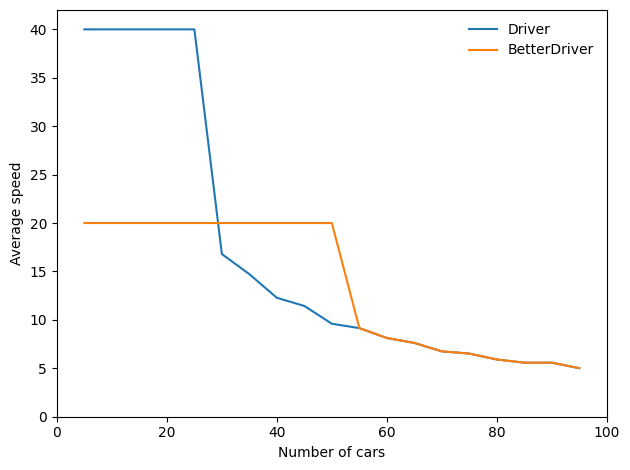

In [14]:
from scipy.integrate import trapezoid

for constructor in [Driver, BetterDriver]:
    xs, ys = run_simulation(eps=0.0, constructor=constructor)
    plt.plot(xs, ys, label=constructor.__name__)
    print(constructor.__name__, trapezoid(ys, xs))
    
decorate(xlabel='Number of cars',
                 ylabel='Average speed',
                 xlim=[0, 100], ylim=[0, 42])

`BetterDriver` is a little better in the sense that it keeps traffic moving smoothly at medium densities. However:

* At high densities, it has almost no effect, and

* At low densities, it is substantially worse.

As a result, the total are under the curve is much less.

See if you can write rules for the agents that maximize the area under the curve.

**Exercise:** The code for my Boid implementation is in `Boids7.py` in the repository for this book. To run it, you will need VPython, a library for 3-D graphics and animation, which you can install by running the following in a terminal:

```
pip install vpython
```

Then run `Boids7.py`. It should either launch a browser or create a window in a running browser, and create an animated display showing Boids, as white cones, circling a red sphere, which is the carrot. If you click and move the mouse, you can move the carrot and see how the Boids react.

Read the code to see how the parameters control Boid behaviors. Experiment with different parameters. What happens if you "turn off" one of the behaviors by setting its weight to 0?

To generate more bird-like behavior, Flake suggests adding a behavior to maintain a clear line of sight; in other words, if there is another bird directly ahead, the Boid should move away laterally. What effect do you expect this rule to have on the behavior of the flock? Implement it and see.

**Exercise:** Read more about free will at <https://thinkcomplex.com/will>. The view that free will is compatible with determinism is called **compatibilism**. One of the strongest challenges to compatibilism is the "consequence argument". What is the consequence argument? What response can you give to the consequence argument based on what you have read in this book?

[Think Complexity, 2nd Edition](https://greenteapress.com/wp/think-complexity-2e/)

Copyright 2016 [Allen B. Downey](https://allendowney.com)

Code license: [MIT License](https://mit-license.org/)

Text license: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)